In [1]:
!pip install seaborn
!pip install  plotly
!pip install imblearn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#import seaborn as sns
#import plotly
# Esto es para que se actualicen los cambios en los archivos importados
%load_ext autoreload
%autoreload 2

In [4]:
test = pd.read_csv('higgs-boson/test/test.csv')
dataset = pd.read_csv('higgs-boson/training/training.csv')

In [5]:
test.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_phi,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt
0,350000,-999.000,79.589,23.916,3.036,-999.000,-999.000,-999.000,0.903,3.036,...,2.022,98.556,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,-0.000
1,350001,106.398,67.490,87.949,49.994,-999.000,-999.000,-999.000,2.048,2.679,...,-1.138,176.251,1,47.575,-0.553,-0.849,-999.000,-999.000,-999.000,47.575
2,350002,117.794,56.226,96.358,4.137,-999.000,-999.000,-999.000,2.755,4.137,...,-1.868,111.505,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
3,350003,135.861,30.604,97.288,9.104,-999.000,-999.000,-999.000,2.811,9.104,...,1.172,164.707,0,-999.000,-999.000,-999.000,-999.000,-999.000,-999.000,0.000
4,350004,74.159,82.772,58.731,89.646,1.347,536.663,-0.339,1.028,77.213,...,-0.231,869.614,3,254.085,-1.013,-0.334,185.857,0.335,2.587,599.213


In [6]:
dataset.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight,Label
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653,s
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584,b
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389,b
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378,b
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333,b


In [20]:
#weights = dataset['Weight']
#y = dataset['Label']

#X = dataset.copy()
#
#X = X.drop(['Weight', 'Label'], axis=1)
#event_id = dataset['EventId']
#X.set_index('EventId')

weights = dataset['Weight']
y = dataset['Label']

X = dataset.copy()
#
X = X.drop(['Label'], axis=1)
event_id = dataset['EventId']
X.set_index('EventId')

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight
EventId,,,,,,,,,,,,,,,,,,,,,
100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,...,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653
100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,125.157,...,164.546,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584
100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,197.814,...,260.414,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389
100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,75.968,...,86.062,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378
100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,57.983,...,53.131,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349995,-999.000,71.989,36.548,5.042,-999.00,-999.000,-999.000,1.392,5.042,55.892,...,144.665,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,4.505083
349996,-999.000,58.179,68.083,22.439,-999.00,-999.000,-999.000,2.585,22.439,50.618,...,80.408,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,2.497259
349997,105.457,60.526,75.839,39.757,-999.00,-999.000,-999.000,2.390,22.183,120.462,...,198.907,1,41.992,1.800,-0.166,-999.000,-999.00,-999.000,41.992,0.018636


In [21]:
X.head()

,EventId,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight
0,100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,...,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653
1,100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,...,164.546,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584
2,100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,...,260.414,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389
3,100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,...,86.062,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378
4,100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,...,53.131,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333


In [22]:
y.head()

0    s
1    b
2    b
3    b
4    b
Name: Label, dtype: object

In [23]:
weights.head()

0    0.002653
1    2.233584
2    2.347389
3    5.446378
4    6.245333
Name: Weight, dtype: float64

Text(0.5, 1.0, 'Proporción s vs b')

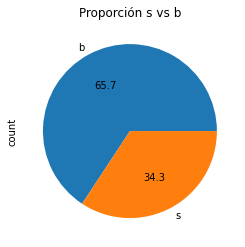

In [24]:
ax= y.value_counts().plot.pie(autopct='%.1f')
ax.set_title('Proporción s vs b')


In [11]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject


In [26]:
#weights = dataset['Weight']
y_os = dataset['Label']

X_os = dataset.copy()
#
X_os = X_os.drop(['Label'], axis=1)
event_id = dataset['EventId']
X.set_index('EventId')

,DER_mass_MMC,DER_mass_transverse_met_lep,DER_mass_vis,DER_pt_h,DER_deltaeta_jet_jet,DER_mass_jet_jet,DER_prodeta_jet_jet,DER_deltar_tau_lep,DER_pt_tot,DER_sum_pt,...,PRI_met_sumet,PRI_jet_num,PRI_jet_leading_pt,PRI_jet_leading_eta,PRI_jet_leading_phi,PRI_jet_subleading_pt,PRI_jet_subleading_eta,PRI_jet_subleading_phi,PRI_jet_all_pt,Weight
EventId,,,,,,,,,,,,,,,,,,,,,
100000,138.470,51.655,97.827,27.980,0.91,124.711,2.666,3.064,41.928,197.760,...,258.733,2,67.435,2.150,0.444,46.062,1.24,-2.475,113.497,0.002653
100001,160.937,68.768,103.235,48.146,-999.00,-999.000,-999.000,3.473,2.078,125.157,...,164.546,1,46.226,0.725,1.158,-999.000,-999.00,-999.000,46.226,2.233584
100002,-999.000,162.172,125.953,35.635,-999.00,-999.000,-999.000,3.148,9.336,197.814,...,260.414,1,44.251,2.053,-2.028,-999.000,-999.00,-999.000,44.251,2.347389
100003,143.905,81.417,80.943,0.414,-999.00,-999.000,-999.000,3.310,0.414,75.968,...,86.062,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,5.446378
100004,175.864,16.915,134.805,16.405,-999.00,-999.000,-999.000,3.891,16.405,57.983,...,53.131,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,6.245333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
349995,-999.000,71.989,36.548,5.042,-999.00,-999.000,-999.000,1.392,5.042,55.892,...,144.665,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,0.000,4.505083
349996,-999.000,58.179,68.083,22.439,-999.00,-999.000,-999.000,2.585,22.439,50.618,...,80.408,0,-999.000,-999.000,-999.000,-999.000,-999.00,-999.000,-0.000,2.497259
349997,105.457,60.526,75.839,39.757,-999.00,-999.000,-999.000,2.390,22.183,120.462,...,198.907,1,41.992,1.800,-0.166,-999.000,-999.00,-999.000,41.992,0.018636


In [27]:
ros =  RandomOverSampler(sampling_strategy= 'not majority', random_state=42 )
X_res, y_res = ros.fit_resample(X_os,y)
weights_res = X_res['Weight']
X_res = X_res.drop(['Weight'], axis=1)

Text(0.5, 1.0, 'Proporción s vs b')

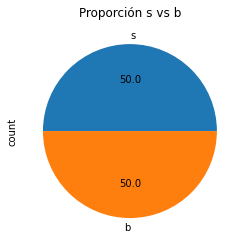

In [28]:
ax= y_res.value_counts().plot.pie(autopct='%.1f')
ax.set_title('Proporción s vs b')

In [32]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_encoded_res = encoder.fit_transform(y_res)
print(y_encoded[:10])

[1 0 0 0 0 0 1 1 0 1]


In [33]:
from sklearn.model_selection import train_test_split

X_train_res, X_test_res, y_train_res, y_test_res, weights_train_res, weights_test_res = train_test_split(X_res, y_encoded_res, weights_res, test_size=0.20, random_state=4546546)

X_val_res, X_test_res, y_val_res, y_test_res, weights_val_res, weights_test_res  = train_test_split(X_test_res, y_test_res, weights_test_res,  test_size=0.25, random_state=4546546)

In [35]:
X_train, X_test, y_train, y_test, weights_train, weights_test = train_test_split(X, y_encoded, weights, test_size=0.20, random_state=4546546)

X_val, X_test, y_val, y_test, weights_val, weights_test  = train_test_split(X_test, y_test, weights_test,  test_size=0.25, random_state=4546546)

In [39]:
from preprocess import std_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import accuracy_score
from sklearn import svm
from sklearn.linear_model import LogisticRegression

std_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('std_scaler', StandardScaler()),
    ])

X_train_res = std_pipeline.fit_transform(X_train_res)
X_train = std_pipeline.fit_transform(X_train)

classifier_logreg_res = LogisticRegression(max_iter=1000, class_weight='balanced')
classifier_logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
classifier_logreg_res.fit(X_train_res, pd.Series(y_train_res),sample_weight=weights_train_res)
classifier_logreg.fit(X_train, pd.Series(y_train),sample_weight=weights_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [43]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score

y_pred_logreg_res = classifier_logreg_res.predict(X_test_res)

conf_matrix_res = confusion_matrix(y_test_res, y_pred_logreg_res, sample_weight=weights_test_res)

precision_res = precision_score(y_test_res, y_pred_logreg_res, average='binary', sample_weight=weights_test_res)
recall_res = recall_score(y_test_res, y_pred_logreg_res, average='binary', sample_weight=weights_test_res)
f1_res = f1_score(y_test_res, y_pred_logreg_res, average='binary', sample_weight=weights_test_res)
accuracy_res = accuracy_score(y_test_res, y_pred_logreg_res, sample_weight=weights_test_res)

print("RESULTADOS CON RESALMPLER")
print("Matriz de confusión:\n", conf_matrix_res)
print("Precision:", precision_res)
print("Recall:", recall_res)
print("F1 Score:", f1_res)
print("Accuracy Score:", accuracy_res)

c:\users\fcere\miniconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


RESULTADOS CON RESALMPLER
Matriz de confusión:
 [[2.08013981e+04 5.47201555e+00]
 [6.54290333e+01 1.08194748e-01]]
Precision: 0.019389009024088452
Recall: 0.0016508898990457476
F1 Score: 0.003042706551710587
Accuracy Score: 0.9966031206787431


c:\users\fcere\miniconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


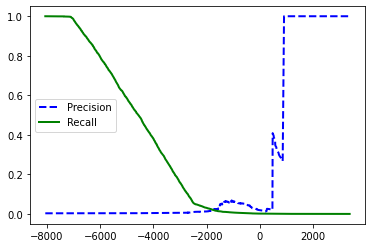

In [45]:
y_test_scores_res = classifier_logreg_res.decision_function(X_test_res)

from sklearn.metrics import precision_recall_curve

precisions_res, recalls_res, thresholds_res = precision_recall_curve(y_test_res, y_test_scores_res, sample_weight=weights_test_res)

plt.plot(thresholds_res, precisions_res[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds_res, recalls_res[:-1], "g-", label="Recall", linewidth=2)
#plt.vlines(thresholds, 0, 1.0, "k", "dotted", label="threshold")
plt.legend()
plt.show()

In [46]:
y_pred_logreg = classifier_logreg.predict(X_test)

conf_matrix = confusion_matrix(y_test, y_pred_logreg, sample_weight=weights_test)

precision = precision_score(y_test, y_pred_logreg, average='binary', sample_weight=weights_test)
recall = recall_score(y_test, y_pred_logreg, average='binary', sample_weight=weights_test)
f1 = f1_score(y_test, y_pred_logreg, average='binary', sample_weight=weights_test)
accuracy = accuracy_score(y_test, y_pred_logreg, sample_weight=weights_test)

print("RESULTADOS POR DEFECTO")
print("Matriz de confusión:\n", conf_matrix)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Accuracy Score:", accuracy)

RESULTADOS POR DEFECTO
Matriz de confusión:
 [[1.09364648e+02 2.01584642e+04]
 [1.84927820e-01 3.40096687e+01]]
Precision: 0.0016842744906428592
Recall: 0.9945918993250525
F1 Score: 0.003362854213841937
Accuracy Score: 0.007062070276246608


c:\users\fcere\miniconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


c:\users\fcere\miniconda3\lib\site-packages\sklearn\base.py:458: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


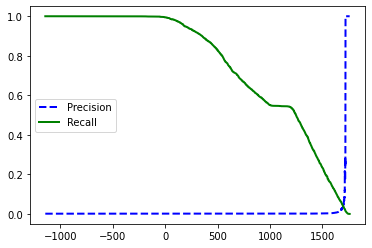

In [48]:
y_test_scores = classifier_logreg.decision_function(X_test)

from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_scores, sample_weight=weights_test)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
#plt.vlines(thresholds, 0, 1.0, "k", "dotted", label="threshold")
plt.legend()
plt.show()

In [43]:
b =dataset.loc[dataset['Label']=='b']['Weight'].sum()
s =dataset.loc[dataset['Label']=='s']['Weight'].sum()

In [51]:
print('porsentaje real s', s*100/(s+b) )

porsentaje real s 0.1680841219865549


In [47]:
print('porsentaje real b', b*100/(s+b) )

porsentaje real b 99.83191587801345


Text(0.5, 1.0, 'Proporción s vs b')

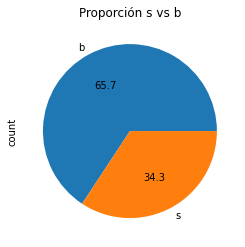

In [45]:
ax= y.value_counts().plot.pie(autopct='%.1f')
ax.set_title('Proporción s vs b')
